# SimCLR Prototype Inference
### Rust / Corrosion Detection

Uses a pretrained SimCLR encoder with prototype-based classification and rejection thresholding.

**Steps:**
- **Section 1** — Setup & Config
- **Section 2** — Build Bundle (run once to compute prototypes)
- **Section 3** — Single Image Inference
- **Section 4** — Folder Inference

## Section 1 — Setup & Config

In [1]:
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [2]:
# Config

DEVICE      = torch.device("mps" if torch.backends.mps.is_available()
                           else "cuda" if torch.cuda.is_available()
                           else "cpu")

SIMCLR_CKPT = Path("simclr_best.pt")
BUNDLE_PATH = Path("simclr_prototype_bundle.pt")
TRAIN_DIR   = Path("rust_dataset/train")
IMG_SIZE    = 224
THRESHOLD   = 0.60    # cosine similarity threshold — lower = more permissive
NUM_WORKERS = 0

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

print("Device:", DEVICE)

Device: mps


In [3]:
# SimCLR model

class SimCLR(nn.Module):
    def __init__(self, proj_dim=128):
        super().__init__()
        base = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.encoder   = nn.Sequential(*list(base.children())[:-1])
        self.feat_dim  = base.fc.in_features
        self.projector = nn.Sequential(
            nn.Linear(self.feat_dim, self.feat_dim),
            nn.ReLU(),
            nn.Linear(self.feat_dim, proj_dim),
        )

    def forward(self, x):
        h = self.encoder(x).squeeze(-1).squeeze(-1)
        z = self.projector(h)
        return h, F.normalize(z, dim=1)

In [4]:
# Transforms and utilities

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

def l2_normalize(Z, eps=1e-12):
    return Z / (Z.norm(dim=1, keepdim=True) + eps)

def extract_features(model, dataloader):
    model.eval()
    all_h, all_labels = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(DEVICE)
            h, _   = model(images)
            all_h.append(h.cpu())
            all_labels.append(labels.cpu())
    return torch.cat(all_h, dim=0), torch.cat(all_labels, dim=0)

def compute_prototypes(H, y, class_names):
    protos = []
    for c in range(len(class_names)):
        mask  = (y == c)
        proto = l2_normalize(H[mask]).mean(dim=0)
        protos.append(proto)
    return l2_normalize(torch.stack(protos, dim=0))

print("Utilities ready.")

Utilities ready.


## Section 2 — Build Bundle

Run this once to compute class prototypes from the training set and save the bundle.
Skip if  already exists.

In [5]:
# Build bundle — load SimCLR, extract train features, compute prototypes

print(f"Loading SimCLR checkpoint from {SIMCLR_CKPT} ...")
model = SimCLR().to(DEVICE)
model.load_state_dict(torch.load(SIMCLR_CKPT, map_location=DEVICE, weights_only=True))
model.eval()
print("Checkpoint loaded.")

Loading SimCLR checkpoint from simclr_best.pt ...
Checkpoint loaded.


In [6]:
# Extract training features

ds = datasets.ImageFolder(TRAIN_DIR, transform=eval_transform)
dl = DataLoader(ds, batch_size=64, shuffle=False, num_workers=NUM_WORKERS)

H, y        = extract_features(model, dl)
class_names = ds.classes
prototypes  = compute_prototypes(H, y, class_names)

print(f"Classes    : {class_names}")
print(f"Features   : {H.shape}")
print(f"Prototypes : {prototypes.shape}")

Classes    : ['CORROSION', 'HARD_NEGATIVE', 'NOCORROSION']
Features   : torch.Size([2472, 512])
Prototypes : torch.Size([3, 512])


In [7]:
# Save bundle

bundle = {
    "model_state_dict": model.state_dict(),
    "prototypes"      : prototypes,
    "threshold"       : THRESHOLD,
    "class_names"     : class_names,
}

torch.save(bundle, BUNDLE_PATH)
print(f"Bundle saved to {BUNDLE_PATH}")

Bundle saved to simclr_prototype_bundle.pt


## Section 3 — Single Image Inference

In [8]:
# Load bundle

bundle      = torch.load(BUNDLE_PATH, map_location=DEVICE, weights_only=False)
model       = SimCLR().to(DEVICE)
model.load_state_dict(bundle["model_state_dict"])
model.eval()
prototypes  = bundle["prototypes"].to(DEVICE)
threshold   = bundle["threshold"]
class_names = bundle["class_names"]

print(f"Classes  : {class_names}")
print(f"Threshold: {threshold}")

Classes  : ['CORROSION', 'HARD_NEGATIVE', 'NOCORROSION']
Threshold: 0.6


In [9]:
# Predict single image function

def predict_single_image(image_path, show=True, save_annotated=True):
    image_path = Path(image_path)
    image      = Image.open(image_path).convert("RGB")
    x          = eval_transform(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        h, _  = model(x)
        h_l2  = l2_normalize(h)
        sims  = h_l2 @ prototypes.T

        score, pred = sims.max(dim=1)
        score       = float(score.item())
        pred        = int(pred.item())

    nearest_class = class_names[pred]
    accepted      = score >= threshold
    label         = nearest_class if accepted else "REJECT"

    result = {
        "image"        : str(image_path),
        "label"        : label,
        "accepted"     : accepted,
        "nearest_class": nearest_class,
        "score"        : round(score, 4),
        "threshold"    : threshold,
        "similarities" : {cls: round(float(s), 4)
                           for cls, s in zip(class_names, sims.squeeze(0).cpu())},
    }

    if show:
        status = "ACCEPTED" if accepted else "REJECTED"
        color  = "red" if label == "CORROSION" else ("green" if accepted else "gray")

        fig, axes = plt.subplots(1, 2, figsize=(10, 4))

        # image panel
        axes[0].imshow(image)
        axes[0].set_title(f"{label}  ({status})", color=color, fontsize=13, fontweight="bold")
        axes[0].axis("off")

        # similarity bar chart
        classes = list(result["similarities"].keys())
        scores  = list(result["similarities"].values())
        colors  = ["tomato" if c == nearest_class else "steelblue" for c in classes]
        axes[1].barh(classes, scores, color=colors)
        axes[1].axvline(threshold, color="black", linestyle="--", label=f"threshold={threshold}")
        axes[1].set_xlabel("Cosine Similarity")
        axes[1].set_title("Prototype Similarities")
        axes[1].legend()
        axes[1].set_xlim(0, 1)

        plt.suptitle(f"{image_path.name}  |  score={score:.4f}", fontsize=11)
        plt.tight_layout()
        plt.show()

    if save_annotated and accepted:
        out_dir   = Path("annotated_results")
        out_dir.mkdir(exist_ok=True)
        annotated = image.copy()
        draw      = ImageDraw.Draw(annotated)
        color_box = "red" if label == "CORROSION" else "green"
        draw.rectangle([0, 0, annotated.width, 30], fill=color_box)
        draw.text((5, 5), f"{label}  {score:.2f}", fill="white")
        annotated.save(out_dir / image_path.name)
        result["annotated_path"] = str(out_dir / image_path.name)

    return result

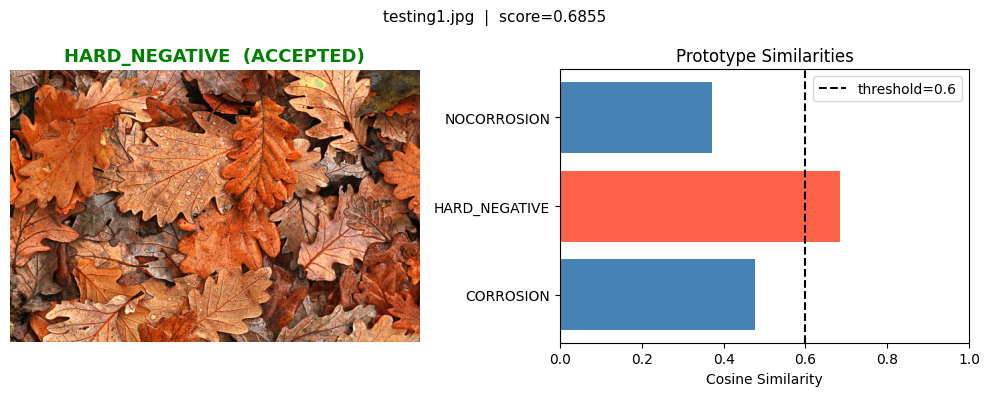

{'image': 'testing1.jpg', 'label': 'HARD_NEGATIVE', 'accepted': True, 'nearest_class': 'HARD_NEGATIVE', 'score': 0.6855, 'threshold': 0.6, 'similarities': {'CORROSION': 0.4768, 'HARD_NEGATIVE': 0.6855, 'NOCORROSION': 0.3711}, 'annotated_path': 'annotated_results/testing1.jpg'}


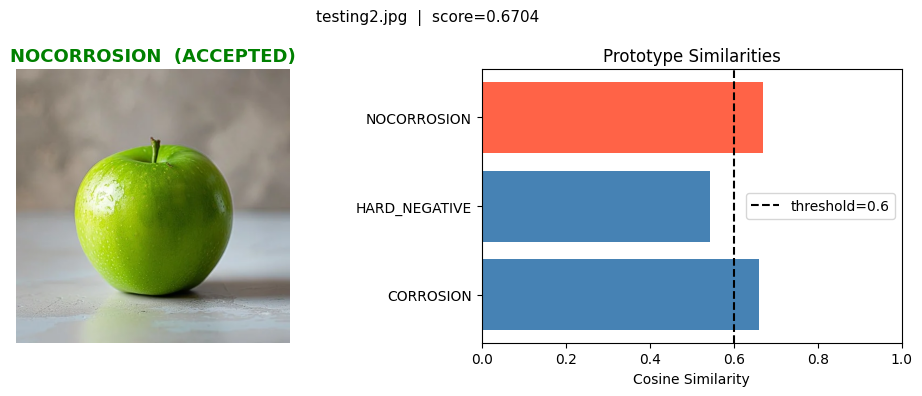

{'image': 'testing2.jpg', 'label': 'NOCORROSION', 'accepted': True, 'nearest_class': 'NOCORROSION', 'score': 0.6704, 'threshold': 0.6, 'similarities': {'CORROSION': 0.6592, 'HARD_NEGATIVE': 0.5439, 'NOCORROSION': 0.6704}, 'annotated_path': 'annotated_results/testing2.jpg'}


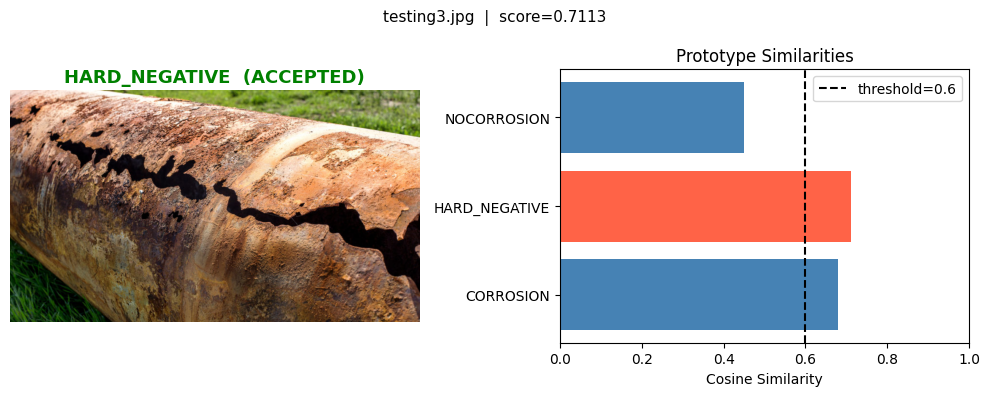

{'image': 'testing3.jpg', 'label': 'HARD_NEGATIVE', 'accepted': True, 'nearest_class': 'HARD_NEGATIVE', 'score': 0.7113, 'threshold': 0.6, 'similarities': {'CORROSION': 0.6807, 'HARD_NEGATIVE': 0.7113, 'NOCORROSION': 0.4496}, 'annotated_path': 'annotated_results/testing3.jpg'}


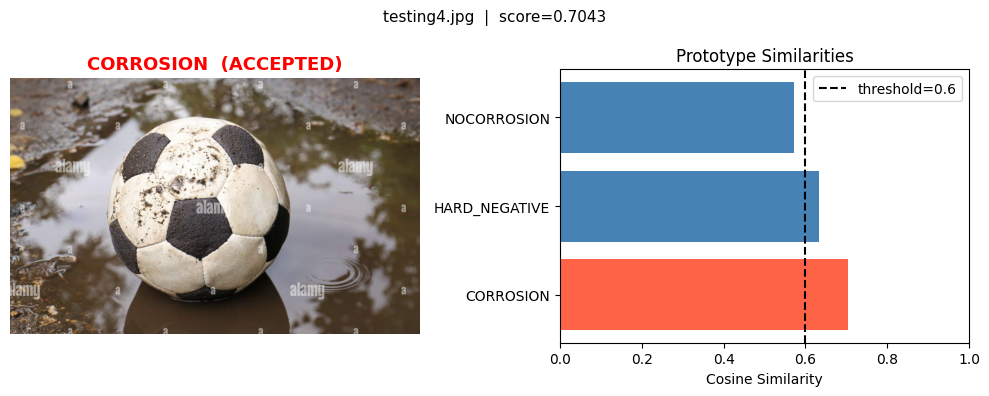

{'image': 'testing4.jpg', 'label': 'CORROSION', 'accepted': True, 'nearest_class': 'CORROSION', 'score': 0.7043, 'threshold': 0.6, 'similarities': {'CORROSION': 0.7043, 'HARD_NEGATIVE': 0.6334, 'NOCORROSION': 0.5733}, 'annotated_path': 'annotated_results/testing4.jpg'}


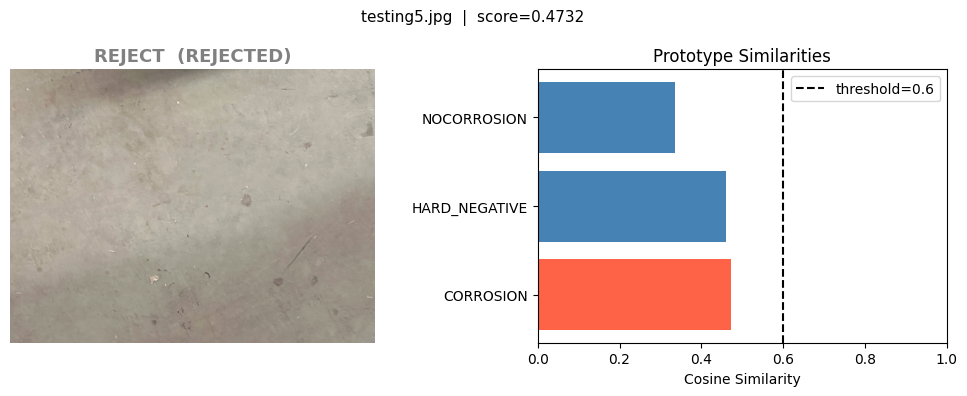

{'image': 'testing5.jpg', 'label': 'REJECT', 'accepted': False, 'nearest_class': 'CORROSION', 'score': 0.4732, 'threshold': 0.6, 'similarities': {'CORROSION': 0.4732, 'HARD_NEGATIVE': 0.4591, 'NOCORROSION': 0.336}}


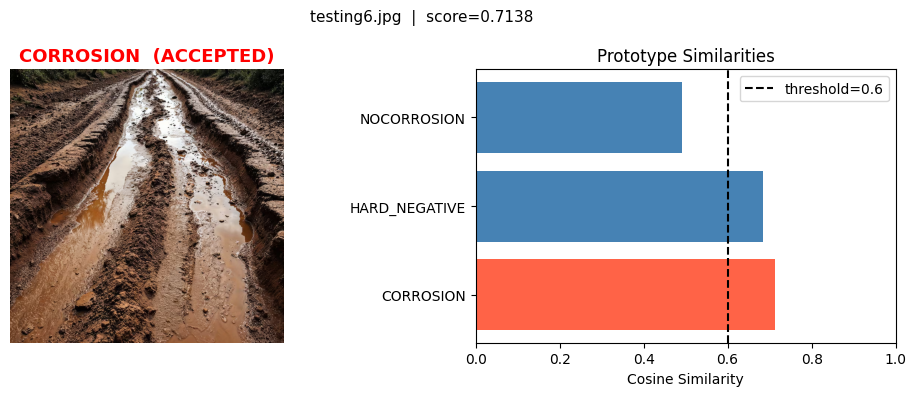

{'image': 'testing6.jpg', 'label': 'CORROSION', 'accepted': True, 'nearest_class': 'CORROSION', 'score': 0.7138, 'threshold': 0.6, 'similarities': {'CORROSION': 0.7138, 'HARD_NEGATIVE': 0.6834, 'NOCORROSION': 0.4906}, 'annotated_path': 'annotated_results/testing6.jpg'}


In [14]:
# Run on a single image — change the path below

IMAGE_PATH = "testing1.jpg"   # <-- update this

result = predict_single_image(IMAGE_PATH)
print(result)

IMAGE_PATH = "testing2.jpg"   # <-- update this

result = predict_single_image(IMAGE_PATH)
print(result)
IMAGE_PATH = "testing3.jpg"   # <-- update this

result = predict_single_image(IMAGE_PATH)
print(result)
IMAGE_PATH = "testing4.jpg"   # <-- update this

result = predict_single_image(IMAGE_PATH)
print(result)
IMAGE_PATH = "testing5.jpg"   # <-- update this

result = predict_single_image(IMAGE_PATH)
print(result)
IMAGE_PATH = "testing6.jpg"   # <-- update this

result = predict_single_image(IMAGE_PATH)
print(result)

## Section 4 — Folder Inference

In [12]:
# Predict all images in a folder

def predict_folder(folder_path):
    folder  = Path(folder_path)
    images  = sorted(folder.glob("*.jpg")) + sorted(folder.glob("*.png"))
    results = []

    print(f"Running inference on {len(images)} images ...")
    for img_path in images:
        result = predict_single_image(img_path, show=False, save_annotated=True)
        status = "ACCEPTED" if result["accepted"] else "REJECTED"
        print(f"  {img_path.name:30s} | {result['label']:12s} | score={result['score']:.4f} | {status}")
        results.append(result)

    accepted  = [r for r in results if r["accepted"]]
    rejected  = [r for r in results if not r["accepted"]]
    corrosion = [r for r in accepted if r["label"] == "CORROSION"]

    print(f"{'='*50}")
    print(f"Total    : {len(results)}")
    print(f"Accepted : {len(accepted)}")
    print(f"Rejected : {len(rejected)}")
    if accepted:
        print(f"  CORROSION   : {len(corrosion)}")
        print(f"  NOCORROSION : {len(accepted) - len(corrosion)}")

    return results

In [13]:
# Run on a folder — change the path below

FOLDER_PATH = "rust_dataset/test/CORROSION"   # <-- update this

results = predict_folder(FOLDER_PATH)

Running inference on 135 images ...
  000009.jpg                     | HARD_NEGATIVE | score=0.6600 | ACCEPTED
  000014.jpg                     | CORROSION    | score=0.7299 | ACCEPTED
  000016.jpg                     | CORROSION    | score=0.7717 | ACCEPTED
  000018.jpg                     | CORROSION    | score=0.7706 | ACCEPTED
  000031.jpg                     | CORROSION    | score=0.7650 | ACCEPTED
  000034.jpg                     | CORROSION    | score=0.8296 | ACCEPTED
  000140.jpg                     | CORROSION    | score=0.7144 | ACCEPTED
  000151.jpg                     | CORROSION    | score=0.7451 | ACCEPTED
  000152.jpg                     | CORROSION    | score=0.7414 | ACCEPTED
  000192.jpg                     | HARD_NEGATIVE | score=0.7003 | ACCEPTED
  000197.jpg                     | CORROSION    | score=0.6855 | ACCEPTED
  000223.jpg                     | CORROSION    | score=0.6693 | ACCEPTED
  000231.jpg                     | CORROSION    | score=0.6928 | ACCEPTED
